In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Day15_Executive_Hotel_Booking_EDA_Dataset.csv")

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print('Raw shape:', df.shape)
display(df.head())
display(df.dtypes.to_frame('dtype'))

Saving Day15_Executive_Hotel_Booking_EDA_Dataset.csv to Day15_Executive_Hotel_Booking_EDA_Dataset (1).csv
Raw shape: (25180, 35)


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Country,Market_Segment,Distribution_Channel,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Room_Type_Reserved,Room_Type_Assigned,Booking_Changes,Deposit_Type,Agent_ID,Company_ID,Days_In_Waiting_List,Customer_Type,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,0,ARE,Direct,Direct,1,0,6,H,H,0,Non Refund,103.0,NaN,5,Contract,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,0,JPN,Groups,Direct,0,0,0,H,H,0,No Deposit,80.0,NaN,3,Contract,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,0,POL,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,53.0,NaN,2,Transient,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,0,CAN,Offline TA/TO,TA/TO,0,0,0,H,H,3,No Deposit,96.0,NaN,0,Contract,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,0,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,51.0,NaN,3,Group,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


,dtype
Booking_ID,object
Hotel_Type,object
Hotel_Location,object
Booking_Date,object
Arrival_Date,object
Lead_Time_Days,int64
Weekend_Nights,int64
Weekday_Nights,int64
Adults,int64
Children,float64


In [4]:
quality = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_n': df.isna().sum(),
    'missing_pct': (df.isna().mean()*100).round(2),
    'n_unique': df.nunique(dropna=True)
}).sort_values('missing_n', ascending=False)
display(quality)

print('Exact duplicate rows:', df.duplicated().sum())
print('Duplicate Booking_IDs:', df['Booking_ID'].duplicated().sum())

for c in ['Hotel_Type','Market_Segment','Meal_Type','Hotel_Location','Reservation_Status']:
    print(f'\n{c}:')
    display(df[c].value_counts(dropna=False).head(15))

bd = pd.to_datetime(df['Booking_Date'], errors='coerce')
ad = pd.to_datetime(df['Arrival_Date'], errors='coerce')
print('Arrival before booking:', (ad < bd).sum())

numeric_cols = df.select_dtypes(include=np.number).columns
display(df[numeric_cols].describe().T)

,dtype,missing_n,missing_pct,n_unique
Company_ID,float64,20729,82.32,119
Country,object,466,1.85,24
Agent_ID,float64,304,1.21,179
Meal_Type,object,245,0.97,9
Satisfaction_Score,float64,164,0.65,276
Children,float64,121,0.48,5
Hotel_Location,object,106,0.42,11
ADR,float64,82,0.33,13269
Booking_ID,object,0,0.00,25000
Hotel_Type,object,0,0.00,5


Exact duplicate rows: 180
Duplicate Booking_IDs: 180

Hotel_Type:


,count
Hotel_Type,
City Hotel,15606
Resort Hotel,9454
CITY HOTEL,44
city hotel,43
City hotel,33



Market_Segment:


,count
Market_Segment,
Online TA,10782
Offline TA/TO,5483
Direct,3827
Corporate,3012
Groups,1924
ONLINE TA,53
online ta,51
Online TA,48


...

,count
Hotel_Location,
Dubai,3171
Lisbon,3168
London,3130
Barcelona,3082
Amsterdam,3055
Goa,1966
Algarve,1920
Bali,1893
Maldives,1857



Reservation_Status:


,count
Reservation_Status,
Canceled,16723
Check-Out,7006
No-Show,1451


Arrival before booking: 6


,count,mean,std,min,25%,50%,75%,max
Lead_Time_Days,25180.0,182.200556,105.604452,0.00,91.00,182.000,273.0000,920.00
Weekend_Nights,25180.0,1.240429,1.063802,0.00,0.00,1.000,2.0000,3.00
Weekday_Nights,25180.0,2.451072,2.031003,0.00,1.00,2.000,4.0000,13.00
Adults,25180.0,2.198967,0.662379,1.00,2.00,2.000,2.0000,7.00
Children,25059.0,0.372122,0.657811,0.00,0.00,0.000,1.0000,6.00
Babies,25180.0,0.043050,0.225057,0.00,0.00,0.000,0.0000,2.00
Is_Repeated_Guest,25180.0,0.172597,0.377906,0.00,0.00,0.000,0.0000,1.00
Previous_Cancellations,25180.0,0.038642,0.251403,0.00,0.00,0.000,0.0000,3.00
Previous_Bookings,25180.0,1.117037,2.829046,0.00,0.00,0.000,0.0000,12.00
Booking_Changes,25180.0,0.601191,0.894293,0.00,0.00,0.000,1.0000,4.00


In [5]:
clean = df.drop_duplicates().copy()

# Standardize categorical labels
clean['Hotel_Type'] = clean['Hotel_Type'].str.strip().str.lower().map(
    {'city hotel':'City Hotel', 'resort hotel':'Resort Hotel'}
)
clean['Market_Segment'] = clean['Market_Segment'].str.strip().str.lower().map({
    'online ta':'Online TA', 'offline ta/to':'Offline TA/TO',
    'direct':'Direct', 'corporate':'Corporate', 'groups':'Groups'
})
clean['Meal_Type'] = clean['Meal_Type'].str.strip().str.upper().replace({
    'B&B':'BB', 'UNKNOWN':np.nan, 'UNDEFINED':np.nan
})
clean['Hotel_Location'] = clean['Hotel_Location'].replace({'Unknown':np.nan})

# Dates
for c in ['Booking_Date','Arrival_Date','Reservation_Status_Date']:
    clean[c] = pd.to_datetime(clean[c], errors='coerce')

# Remove logically impossible date records from time-based analysis
invalid_date_mask = clean['Arrival_Date'] < clean['Booking_Date']
invalid_date_count = int(invalid_date_mask.sum())
clean = clean.loc[~invalid_date_mask].copy()

# Invalid satisfaction scores -> missing
invalid_sat = ~clean['Satisfaction_Score'].between(1,5)
invalid_sat_count = int(invalid_sat.sum())
clean.loc[invalid_sat, 'Satisfaction_Score'] = np.nan

# Conservative imputation
clean['Children'] = clean['Children'].fillna(0)
clean['ADR'] = clean['ADR'].fillna(clean.groupby('Hotel_Type')['ADR'].transform('median'))
for c in ['Country','Hotel_Location','Meal_Type']:
    clean[c] = clean[c].fillna('Unknown')
for c in ['Agent_ID','Company_ID']:
    clean[c] = clean[c].fillna(-1).astype(str).replace({'-1.0':'Unknown','-1':'Unknown'})

# Derived features
clean['Booking_Year'] = clean['Booking_Date'].dt.year
clean['Booking_Month'] = clean['Booking_Date'].dt.month
clean['Arrival_Year'] = clean['Arrival_Date'].dt.year
clean['Total_Guests'] = clean['Adults'] + clean['Children'] + clean['Babies']
clean['Lead_Band'] = pd.cut(
    clean['Lead_Time_Days'], [-1,30,90,180,365,1000],
    labels=['0-30','31-90','91-180','181-365','366+']
)

print(f'Removed duplicates: {df.duplicated().sum()}')
print(f'Removed logically inconsistent date rows: {invalid_date_count}')
print(f'Invalid satisfaction scores converted to missing: {invalid_sat_count}')
print('Final analytical shape:', clean.shape)
display(clean.head())

Removed duplicates: 180
Removed logically inconsistent date rows: 6
Invalid satisfaction scores converted to missing: 162
Final analytical shape: (24994, 40)


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Country,Market_Segment,Distribution_Channel,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Room_Type_Reserved,Room_Type_Assigned,Booking_Changes,Deposit_Type,Agent_ID,Company_ID,Days_In_Waiting_List,Customer_Type,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue,Booking_Year,Booking_Month,Arrival_Year,Total_Guests,Lead_Band
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,0,ARE,Direct,Direct,1,0,6,H,H,0,Non Refund,103.0,Unknown,5,Contract,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65,2024,7,2025,2.0,181-365
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,0,JPN,Groups,Direct,0,0,0,H,H,0,No Deposit,80.0,Unknown,3,Contract,Unknown,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43,2024,5,2025,4.0,181-365
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,0,POL,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,53.0,Unknown,2,Transient,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06,2024,5,2024,4.0,31-90
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,0,CAN,Offline TA/TO,TA/TO,0,0,0,H,H,3,No Deposit,96.0,Unknown,0,Contract,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63,2024,3,2024,2.0,0-30
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,0,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,51.0,Unknown,3,Group,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50,2024,8,2025,4.0,181-365


In [6]:
kpis = pd.Series({
    'Bookings': len(clean),
    'Cancellation rate': clean['Is_Canceled'].mean(),
    'Estimated revenue': clean['Estimated_Revenue'].sum(),
    'Average ADR': clean['ADR'].mean(),
    'Average stay (nights)': clean['Total_Nights'].mean(),
    'Average lead time (days)': clean['Lead_Time_Days'].mean(),
    'Repeat guest rate': clean['Is_Repeated_Guest'].mean()
})
display(kpis.to_frame('Value').style.format({
    'Value':'{:,.2f}'
}))

display(clean[['Lead_Time_Days','Total_Nights','Adults','Children','ADR',
               'Total_Special_Requests','Satisfaction_Score','Estimated_Revenue']].describe().T)

,Value
Bookings,"24,994.00"
Cancellation rate,0.72
Estimated revenue,"13,380,827.60"
Average ADR,140.60
Average stay (nights),3.69
Average lead time (days),182.24
Repeat guest rate,0.17


,count,mean,std,min,25%,50%,75%,max
Lead_Time_Days,24994.0,182.236817,105.634124,0.00,91.0000,182.00,273.000,920.00
Total_Nights,24994.0,3.692446,2.085352,1.00,2.0000,4.00,5.000,45.00
Adults,24994.0,2.198408,0.662244,1.00,2.0000,2.00,2.000,7.00
Children,24994.0,0.370569,0.656744,0.00,0.0000,0.00,1.000,6.00
ADR,24994.0,140.601282,47.748096,30.80,105.6925,134.37,168.965,710.50
Total_Special_Requests,24994.0,1.097743,1.048158,0.00,0.0000,1.00,2.000,5.00
Satisfaction_Score,24832.0,3.854403,0.404217,1.95,3.5900,3.86,4.130,5.00
Estimated_Revenue,24994.0,535.361591,389.666158,31.82,230.6200,448.71,737.570,3256.02


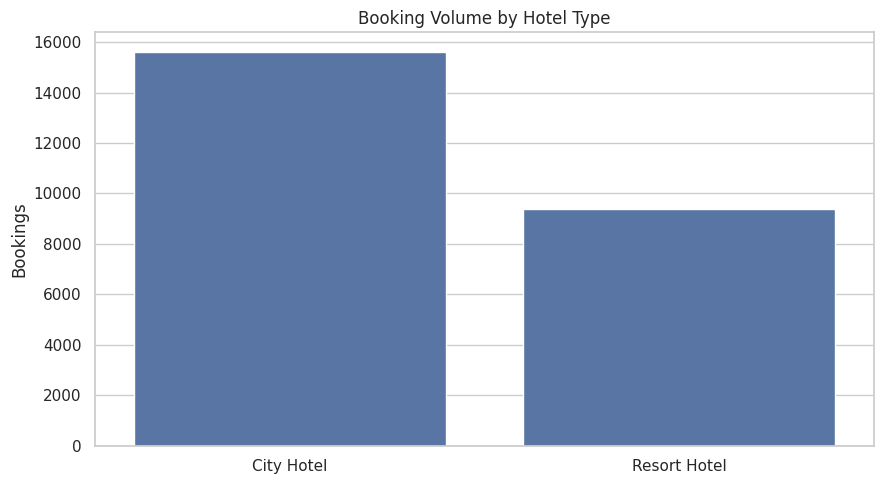

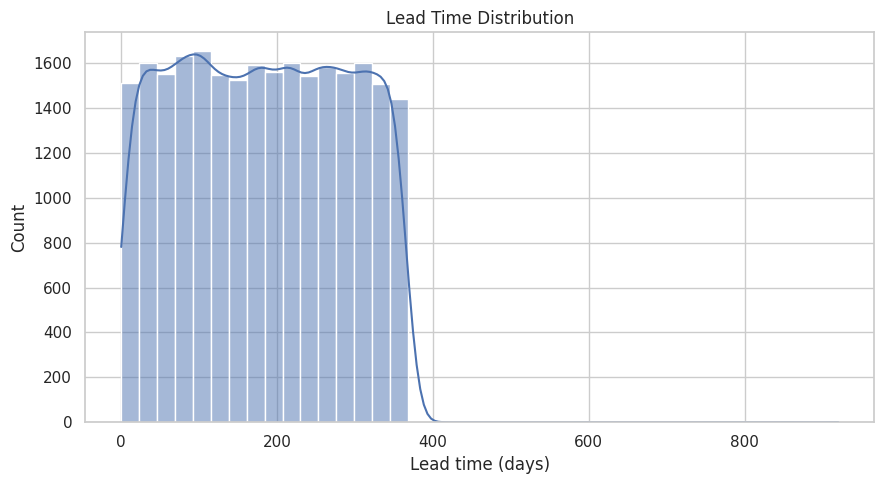

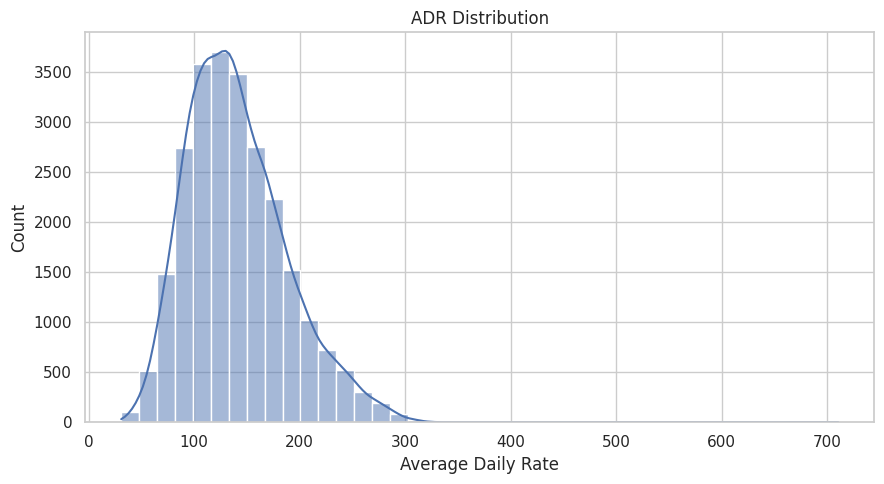

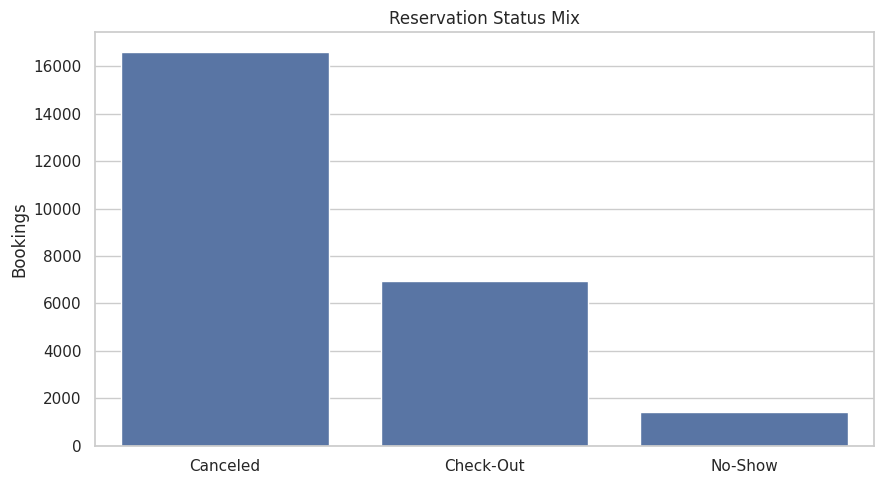

In [7]:
fig, ax = plt.subplots(figsize=(9,5))
sns.countplot(data=clean, x='Hotel_Type', color='C0', ax=ax)
ax.set_title('Booking Volume by Hotel Type')
ax.set_xlabel('')
ax.set_ylabel('Bookings')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9,5))
sns.histplot(data=clean, x='Lead_Time_Days', bins=40, kde=True, color='C0', ax=ax)
ax.set_title('Lead Time Distribution')
ax.set_xlabel('Lead time (days)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9,5))
sns.histplot(data=clean, x='ADR', bins=40, kde=True, color='C0', ax=ax)
ax.set_title('ADR Distribution')
ax.set_xlabel('Average Daily Rate')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9,5))
sns.countplot(data=clean, x='Reservation_Status', order=clean['Reservation_Status'].value_counts().index, color='C0', ax=ax)
ax.set_title('Reservation Status Mix')
ax.set_xlabel('')
ax.set_ylabel('Bookings')
plt.tight_layout()
plt.show()

,Bookings,Cancellation_Rate,Revenue,ADR,Avg_Nights
Hotel_Type,,,,,
City Hotel,15607,73.3%,"6,016,144",120.70,3.20
Resort Hotel,9387,70.3%,"7,364,684",173.68,4.52


,Bookings,Cancellation_Rate,Revenue,ADR,Avg_Nights
Market_Segment,,,,,
Online TA,10851,75.1%,"5,931,588",143.23,3.70
Offline TA/TO,5438,70.4%,"2,942,778",142.40,3.68
Direct,3806,71.2%,"2,097,299",143.26,3.71
Corporate,2989,67.5%,"1,491,928",134.13,3.62
Groups,1910,69.8%,"917,236",125.36,3.74


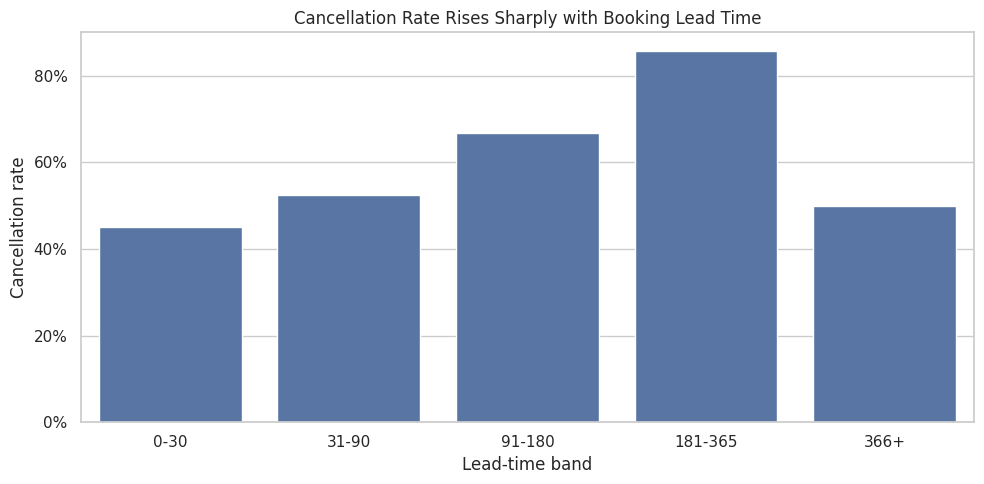

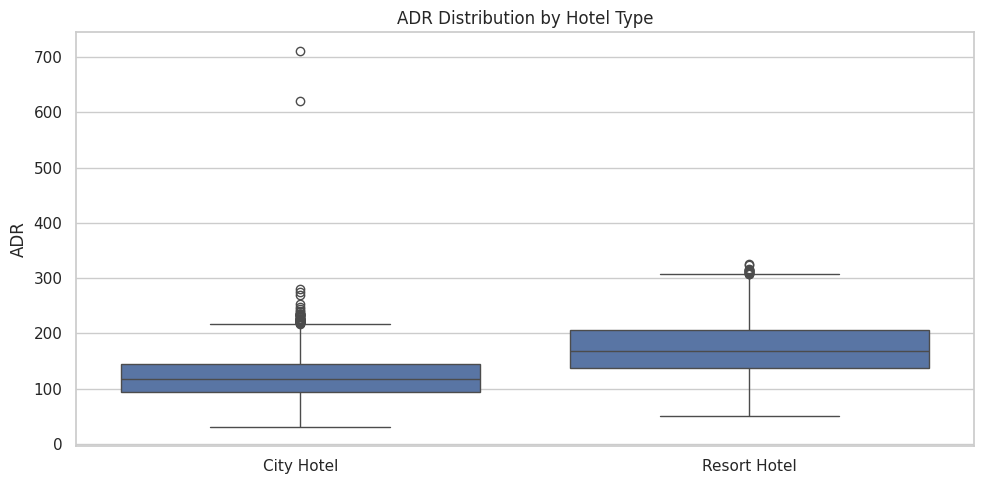

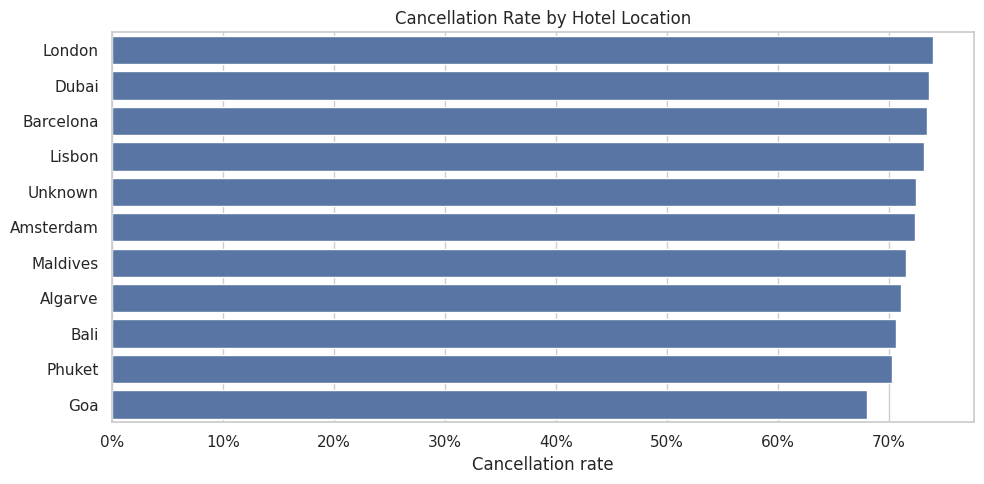

In [8]:
def summary_by(col):
    return clean.groupby(col).agg(
        Bookings=('Booking_ID','size'),
        Cancellation_Rate=('Is_Canceled','mean'),
        Revenue=('Estimated_Revenue','sum'),
        ADR=('ADR','mean'),
        Avg_Nights=('Total_Nights','mean')
    ).sort_values('Bookings', ascending=False)

display(summary_by('Hotel_Type').style.format({
    'Cancellation_Rate':'{:.1%}','Revenue':'{:,.0f}','ADR':'{:,.2f}','Avg_Nights':'{:.2f}'
}))
display(summary_by('Market_Segment').style.format({
    'Cancellation_Rate':'{:.1%}','Revenue':'{:,.0f}','ADR':'{:,.2f}','Avg_Nights':'{:.2f}'
}))

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=clean, x='Lead_Band', y='Is_Canceled', estimator=np.mean, errorbar=None, color='C0', ax=ax)
ax.set_title('Cancellation Rate Rises Sharply with Booking Lead Time')
ax.set_xlabel('Lead-time band')
ax.set_ylabel('Cancellation rate')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=clean, x='Hotel_Type', y='ADR', color='C0', ax=ax)
ax.set_title('ADR Distribution by Hotel Type')
ax.set_xlabel('')
ax.set_ylabel('ADR')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10,5))
loc = clean.groupby('Hotel_Location').agg(Cancellation_Rate=('Is_Canceled','mean'),Bookings=('Booking_ID','size')).sort_values('Cancellation_Rate', ascending=False)
sns.barplot(x=loc['Cancellation_Rate'], y=loc.index, color='C0', ax=ax)
ax.set_title('Cancellation Rate by Hotel Location')
ax.set_xlabel('Cancellation rate')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
plt.tight_layout()
plt.show()

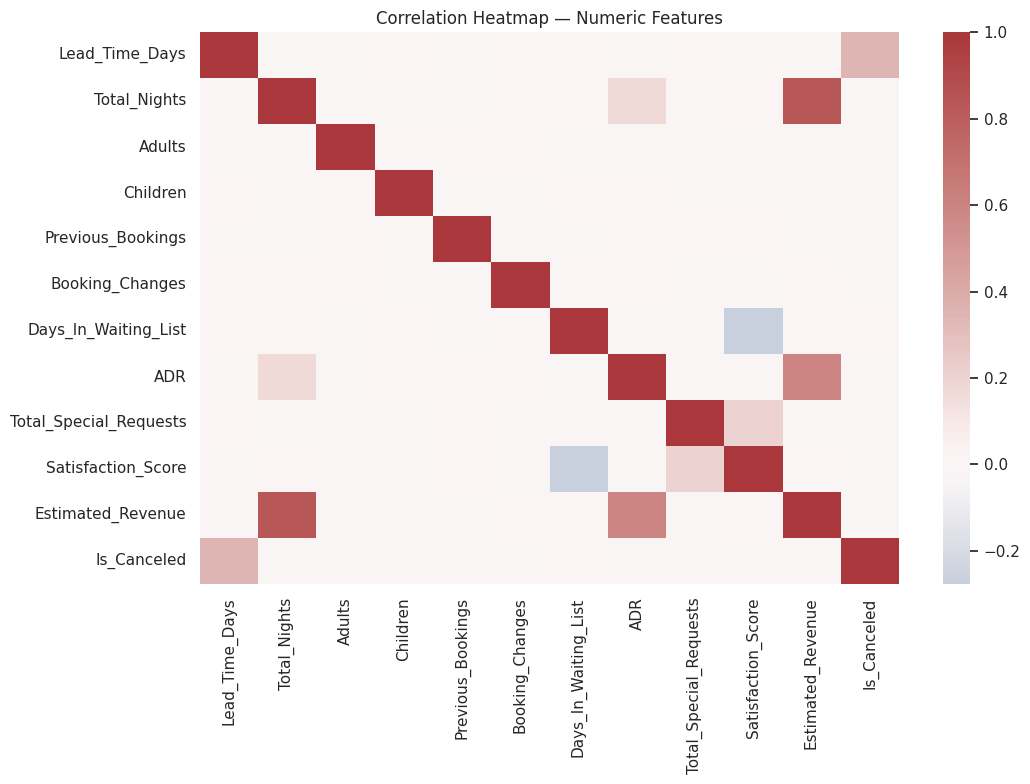

Correlations with cancellation:


,Correlation
Is_Canceled,1.000000
Lead_Time_Days,0.343780
Days_In_Waiting_List,0.003472
Children,-0.001368
Previous_Bookings,-0.001439
Booking_Changes,-0.001933
Total_Special_Requests,-0.003517
Total_Nights,-0.004998
Adults,-0.005430
Satisfaction_Score,-0.010388


Correlations with revenue:


,Correlation
Estimated_Revenue,1.000000
Total_Nights,0.837976
ADR,0.603696
Booking_Changes,0.013039
Days_In_Waiting_List,0.010961
Satisfaction_Score,0.004832
Children,-0.000241
Adults,-0.000589
Previous_Bookings,-0.004580
Lead_Time_Days,-0.008277


In [9]:
corr_cols = ['Lead_Time_Days','Total_Nights','Adults','Children','Previous_Bookings',
              'Booking_Changes','Days_In_Waiting_List','ADR','Total_Special_Requests',
              'Satisfaction_Score','Estimated_Revenue','Is_Canceled']
corr = clean[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11,8))
sns.heatmap(corr, cmap='vlag', center=0, annot=False, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

print('Correlations with cancellation:')
display(corr['Is_Canceled'].sort_values(ascending=False).to_frame('Correlation'))

print('Correlations with revenue:')
display(corr['Estimated_Revenue'].sort_values(ascending=False).to_frame('Correlation'))